# 04 — Downstream READ localization

This phase selects one item from each frozen WRITE/READ quartile cell among notebook-02 raw $W_UJ$ successes. For each item, the source layer is chosen transparently by $|\sum_p WRITE_{l,p}\,READ_{l,p}|$, the source direction is ablated once, and downstream Qwen MLP outputs and pre-`o_proj` head streams are localized with $\nabla M_{clean}\cdot(a_{ablated}-a_{clean})$. These scores overlap and are not an additive causal decomposition. Activation-independent MLP-gain and per-head OV READ scores use seeded random-unit normalization; agreement is descriptive and selection-conditioned. Quartile cells are sampling strata, not preassigned narration/driver classes.

In [1]:
import json
import os
from pathlib import Path

ROOT = Path('/home/jovyan/j-space-thoughts')
os.chdir(ROOT)
os.environ['PIP_USER'] = 'false'
os.environ['PYTHONNOUSERSITE'] = '1'
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
metrics_path = ROOT / 'results/metrics.json'
twohop_path = ROOT / 'data/raw/02_twohop_qwen2.5-7b.json'
assert twohop_path.exists(), 'Notebook 02 raw payload is required'
print('Source payload MiB:', twohop_path.stat().st_size / 2**20)

Source payload MiB: 7.537077903747559


In [2]:
from src.localization_phase import NON_ADDITIVE_WARNING, run_qwen_localization_phase

localization = run_qwen_localization_phase(
    twohop_path=twohop_path,
    output_path=ROOT / 'data/raw/04_localization_qwen2.5-7b.json',
    figure_path=ROOT / 'results/figures/f4_read_localization_qwen2.5-7b.png',
    lower_quantile=0.25,
    upper_quantile=0.75,
    n_per_cell=1,
    n_source_layers=1,
    top_k_mlps=4,
    top_k_heads=8,
    n_random=128,
    seed=1729,
)
print(NON_ADDITIVE_WARNING)

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

/opt/conda/lib/python3.11/site-packages/torch/autograd/graph.py:825: UserWarning: Flash Attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at ../aten/src/ATen/native/transformers/cuda/attention_backward.cu:102.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


LOCALIZATION COMPUTED: items=4, sources=4, direction=jlens_raw_wu_j
Clean-gradient dot (single-source-ablated minus clean) component scores are overlapping first-order mediation/localization diagnostics. Attention and MLP paths, and earlier and later components, overlap; scores must not be summed or interpreted as an additive causal decomposition.


Clean-gradient dot (single-source-ablated minus clean) component scores are overlapping first-order mediation/localization diagnostics. Attention and MLP paths, and earlier and later components, overlap; scores must not be summed or interpreted as an additive causal decomposition.


## Curated metrics versus raw audit trail

The complete per-position component scores and all seeded weight-null draws remain in `data/raw/04_localization_qwen2.5-7b.json`. The versioned metrics file retains selection provenance, every component's scalar localization score, flagged-component weight summaries, and rank-agreement records while removing only repetitive position vectors and raw null arrays.

In [3]:
from src.metrics import save_json

component_keys = ('component', 'layer', 'head', 'score', 'abs_score', 'delta_norm', 'clean_gradient_norm', 'clean_activation_norm', 'perturbed_activation_norm', 'capture')
weight_keys = ('component', 'layer', 'head', 'score', 'abs_score', 'attribution_abs_rank', 'gain', 'normalized_gain', 'random_median', 'gain_random_percentile', 'ov_norm', 'normalized_ov_norm', 'random_median_ov_norm', 'ov_norm_random_percentile', 'label_cosine', 'label_cosine_random_percentile', 'label_weighted_normalized_ov', 'n_random', 'seed', 'weight_metric')
def keep(row, keys):
    return {key: row[key] for key in keys if key in row}

slim_records = []
for record in localization['localizations']:
    loc = record['localization']
    slim_records.append({
        key: record[key] for key in ('name', 'source', 'category', 'intermediate', 'concept_token_id', 'concept_token_surface', 'target_token_id', 'foil_token_id', 'direction_method', 'direction_formula', 'source_layer', 'source_selection_rank', 'source_selection', 'sampling_cell', 'notebook02_summary')
    } | {
        'localization': {
            key: loc[key] for key in ('source_layer', 'component_layers', 'intervention', 'behavior_metric', 'clean_metric', 'perturbed_metric', 'actual_delta', 'positive_damage', 'localization_estimator')
        } | {
            'mlps': [keep(row, component_keys) for row in loc['mlps']],
            'attention_heads': [keep(row, component_keys) for row in loc['attention_heads']],
        },
        'weight_read': {
            'metadata': record['weight_read']['metadata'],
            'mlps': [keep(row, weight_keys) for row in record['weight_read']['mlps']],
            'attention_heads': [keep(row, weight_keys) for row in record['weight_read']['attention_heads']],
        },
    })
curated = {key: localization[key] for key in ('schema_version', 'status', 'metadata', 'selection', 'source_layer_selection', 'sample_counts', 'f4_candidates', 'attribution_weight_rank_agreement', 'figures', 'interpretation_guardrail')}
curated['localizations'] = slim_records
metrics = json.loads(metrics_path.read_text())
metrics.setdefault('localization', {})['qwen2.5-7b-instruct'] = curated
save_json(metrics_path, metrics)
print('Curated localization merged; metrics size MiB:', metrics_path.stat().st_size / 2**20)

Curated localization merged; metrics size MiB: 20.697175979614258


In [4]:
import pandas as pd

display(pd.DataFrame([{
    'item': row['name'],
    'cell': row['sampling_cell'],
    'source_layer': row['source_layer'],
    'WRITE': row['notebook02_summary']['write_strength'],
    'READ': row['notebook02_summary']['read_strength'],
    'single_source_damage': row['localization']['positive_damage'],
} for row in localization['localizations']]))
agreement = localization['attribution_weight_rank_agreement']
display(pd.DataFrame([
    {'comparison': key, 'status': value['status'], 'n': value['n'], 'spearman_rho': value.get('spearman_rho')}
    for key, value in agreement.items() if isinstance(value, dict) and 'status' in value
]))
print('F4 candidates:', localization['f4_candidates'])

,item,cell,source_layer,WRITE,READ,single_source_damage
0,us-detroit-state-capital,high_write_high_read,22,36.434732,0.061943,5.500
1,ex2-language-capital-Hungarian,high_write_low_read,25,29.746318,0.011633,1.250
2,us-san-jose-state-capital,low_write_high_read,22,19.049158,0.070780,8.375
3,func-pumps-chambers,low_write_low_read,23,9.802717,0.005779,0.250


,comparison,status,n,spearman_rho
0,mlp_attribution_vs_normalized_gain,ESTIMATED,14,-0.274725
1,head_attribution_vs_normalized_ov,ESTIMATED,32,0.642595
2,head_attribution_vs_label_weighted_ov,ESTIMATED,32,0.435850


F4 candidates: {'driver_candidate': {'name': 'us-san-jose-state-capital', 'selection_cell': 'low_write_high_read', 'write_strength': 19.049158369004726, 'read_strength': 0.07077994362969346, 'all_band_ablation_positive_damage': 8.9375, 'selection_rule': 'largest measured all-band ablation damage within the sampled high-READ strata; attribution READ and name break ties'}, 'low_read_candidate': {'name': 'ex2-language-capital-Hungarian', 'selection_cell': 'high_write_low_read', 'write_strength': 29.746318355557463, 'read_strength': 0.011633041425444563, 'all_band_ablation_positive_damage': 1.0625, 'selection_rule': 'lowest attribution READ, preferring the high-WRITE/low-READ cell; WRITE and name break ties'}, 'guardrail': 'These are visualization candidates selected after notebook-02 measurements. The low-READ candidate is not declared narration, and the driver label is not an independently validated class assignment.'}


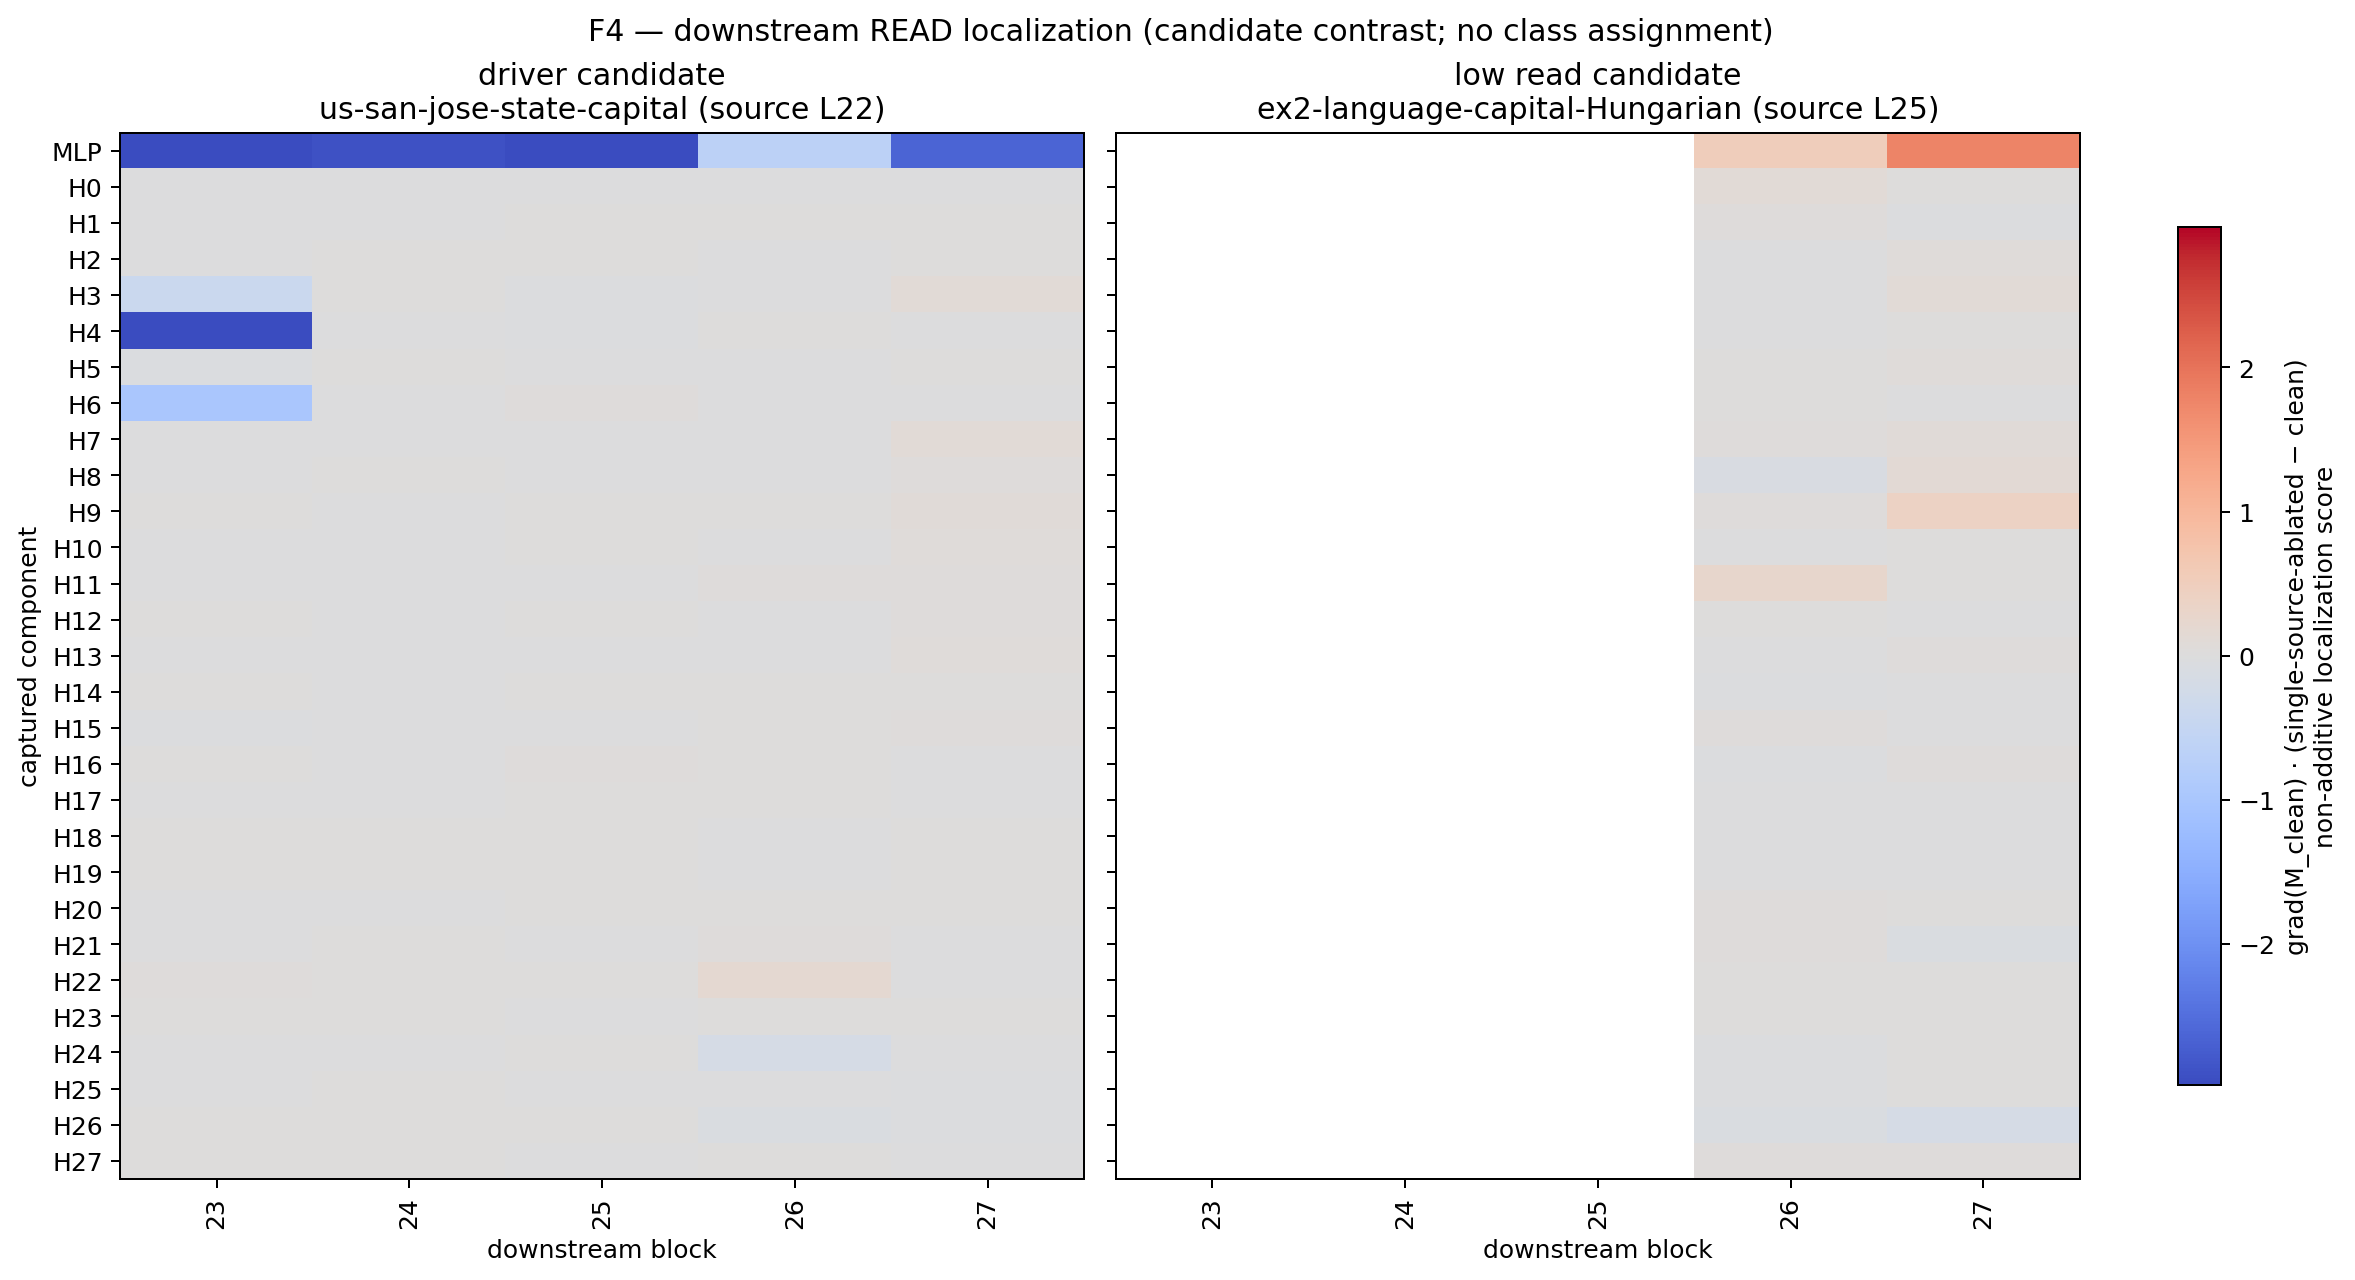

In [5]:
from IPython.display import Image, display

display(Image(filename=localization['figures']['f4']))

In [6]:
print('PHASE 04 COMPUTED')
print('Selected strict quartile cells:', localization['selection']['provenance']['cells'])
print('Weight/attribution agreement is descriptive, selection-conditioned, and not an additive mediation estimate.')

PHASE 04 COMPUTED
Selected strict quartile cells: {'high_write_high_read': {'n_strict_candidates': 12, 'n_selected': 1, 'n_fallback': 0}, 'high_write_low_read': {'n_strict_candidates': 8, 'n_selected': 1, 'n_fallback': 0}, 'low_write_high_read': {'n_strict_candidates': 8, 'n_selected': 1, 'n_fallback': 0}, 'low_write_low_read': {'n_strict_candidates': 12, 'n_selected': 1, 'n_fallback': 0}}
Weight/attribution agreement is descriptive, selection-conditioned, and not an additive mediation estimate.
